In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


# Variables

In [2]:
orig = pd.read_csv("wife.csv")
df = orig[["AgeWhenMarried", "PreviouslyMarried","Outcome"]].dropna()

outcome_map = {
    "Divorced": 0,
    "Executed": 1,
    "Died": 2,
    "Survived": 3
}

df["Outcome"] = df["Outcome"].map(outcome_map)

X = df[["AgeWhenMarried", "PreviouslyMarried"]].values
y = df["Outcome"].values
classes = np.unique(y)



# Model

In [3]:
with pm.Model() as model:

    n_features = X.shape[1]
    #Coefficients for each class
    beta = pm.Normal("beta", mu=0,sigma=1,shape=(len(classes), n_features))
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=len(classes))

    #Linear predictor
    linear_pred = alpha + pm.math.dot(X, beta.T)

    #Softmax probabilities
    p = pm.Deterministic("p",pm.math.softmax(linear_pred, axis=1))

    #Likelihood
    y_obs = pm.Categorical("y_obs",p=p,observed=y)

    trace = pm.sample(chains=4,draws=2000, tune=2000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, alpha]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 679 seconds.


# Summary and Plots

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0, 0]  0.016  0.515  -0.964    0.980      0.009    0.006    3272.0   
beta[0, 1] -0.269  0.968  -2.172    1.501      0.011    0.012    8013.0   
beta[1, 0]  0.016  0.515  -0.977    0.977      0.009    0.006    3277.0   
beta[1, 1] -0.266  0.946  -1.990    1.522      0.010    0.011    8689.0   
beta[2, 0] -0.008  0.515  -0.954    0.987      0.009    0.006    3279.0   
beta[2, 1] -0.159  0.948  -1.937    1.585      0.010    0.011    8671.0   
beta[3, 0] -0.005  0.516  -0.957    0.997      0.009    0.006    3276.0   
beta[3, 1]  0.718  0.939  -1.141    2.392      0.010    0.011    8442.0   
alpha[0]    0.116  0.979  -1.823    1.867      0.010    0.012    8843.0   
alpha[1]    0.119  0.983  -1.748    1.988      0.011    0.012    8114.0   
alpha[2]   -0.103  0.983  -1.937    1.791      0.011    0.012    8638.0   
alpha[3]   -0.184  0.991  -2.076    1.624      0.010    0.012    9202.0   
p[0, 0]     0.323  0.173 

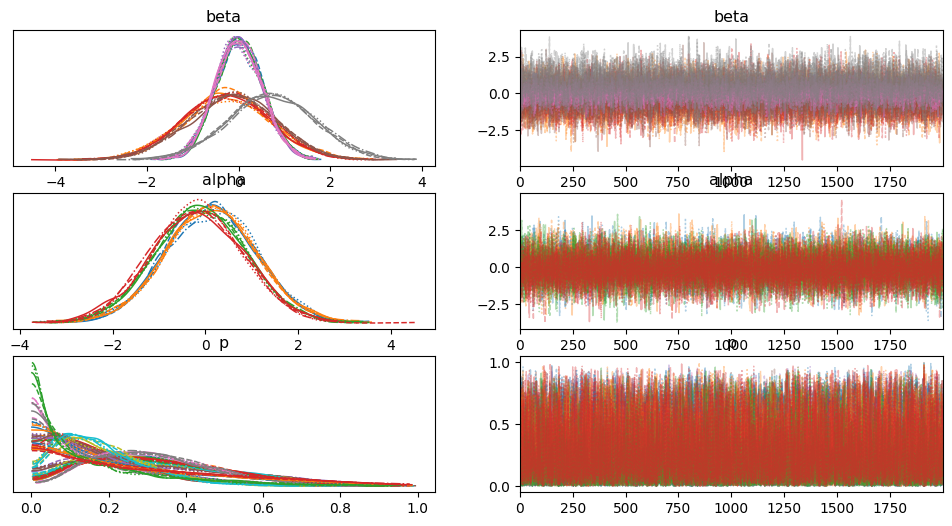

In [4]:
#Get summary and plots
summary = pm.summary(trace)
print(summary)

pm.plot_trace(trace)
plt.show()

# PPC

In [ ]:
#Predict:

with model:
    posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["p"])
pred_probs = posterior_predictive.posterior_predictive["p"].values
pred_classes = np.argmax(pred_probs, axis=2)
print(pred_classes)




Sampling: []


Output()

[[[4 1 4 5]
  [5 1 4 5]
  [1 4 4 5]
  ...
  [5 4 4 4]
  [1 5 5 1]
  [1 5 4 4]]

 [[4 4 1 1]
  [5 1 4 5]
  [4 1 1 5]
  ...
  [1 4 4 5]
  [4 1 1 5]
  [1 4 4 5]]

 [[5 1 1 4]
  [1 0 4 5]
  [4 1 5 4]
  ...
  [5 5 1 4]
  [4 4 1 5]
  [5 2 4 5]]

 [[4 5 4 5]
  [5 4 2 4]
  [5 4 4 3]
  ...
  [1 4 5 5]
  [4 1 4 5]
  [5 0 4 5]]]


# Preparing for Prediction


In [ ]:
alpha = trace.posterior["alpha"].values   # (chains, draws, K)
beta = trace.posterior["beta"].values     # (chains, draws, K, features)

alpha = alpha.reshape(-1, alpha.shape[-1])   # (S, K)
beta = beta.reshape(-1, beta.shape[-2], beta.shape[-1])  # (S, K, p)

import numpy as np
from scipy.special import softmax

def predict_proba(X_new):
    S = alpha.shape[0]
    n = X_new.shape[0]
    K = alpha.shape[1]

    preds = np.zeros((S, n, K))

    for s in range(S):
        logits = alpha[s] + X_new @ beta[s].T
        preds[s] = softmax(logits, axis=1)

    return preds



['Divorced', 'Survived', 'Executed']


# Prediction


In [22]:
X_new = np.array([[25, 0], [30, 1], [35, 0]])  # (n_new, p)
probs = predict_proba(X_new)

mean_probs = probs.mean(axis=0)   # (n_new, K)
pred_classes = np.argmax(mean_probs, axis=1)
inv_outcome_map = {v: k for k, v in outcome_map.items()}
pred_labels = [inv_outcome_map[c] for c in pred_classes]
print(pred_labels)
std_probs = probs.std(axis=0)
print("Predicted probabilities:\n", mean_probs)
print("Standard deviation of probabilities:\n", std_probs)

['Divorced', 'Survived', 'Executed']
Predicted probabilities:
 [[0.32337581 0.32320667 0.18047759 0.17293993]
 [0.270458   0.27044589 0.16340342 0.29569269]
 [0.32835046 0.32852771 0.17478579 0.16833604]]
Standard deviation of probabilities:
 [[0.17782736 0.17579686 0.14156382 0.13487646]
 [0.22179457 0.22017326 0.1760173  0.23543365]
 [0.23167121 0.22988889 0.18089186 0.17344772]]


# Experimental Prediction

In [30]:
import numpy as np
from scipy.special import softmax

def what_if_wife(trace, AgeWhenMarried, PreviouslyMarried):
    """
    Returns risk profile for a hypothetical wife.
    """

    # ---- Encode input ----
    # Keep consistent with training feature order:
    # X = [AgeWhenMarried, PreviouslyMarried, Religion]

    x = np.array([
        AgeWhenMarried,
        PreviouslyMarried,
        # Religion if Religion is not None else 0
    ])

    # ---- Extract posterior ----
    alpha = trace.posterior["alpha"].values
    beta = trace.posterior["beta"].values

    alpha = alpha.reshape(-1, alpha.shape[-1])      # (S, K)
    beta = beta.reshape(-1, beta.shape[-2], beta.shape[-1])  # (S, K, p)

    S = alpha.shape[0]
    K = alpha.shape[1]

    probs = np.zeros((S, K))

    # ---- Posterior predictive ----
    for s in range(S):
        logits = alpha[s] + beta[s] @ x
        probs[s] = softmax(logits)

    mean_probs = probs.mean(axis=0)
    std_probs = probs.std(axis=0)

    outcomes = ["Divorced", "Died", "Survived", "Executed"]

    return {
        "mean_prob": dict(zip(outcomes, mean_probs)),
        "std_prob": dict(zip(outcomes, std_probs))
    }

In [ ]:
result = what_if_wife(
    trace,
    AgeWhenMarried=22,
    PreviouslyMarried=0
)

print(result["mean_prob"])

{'Divorced': np.float64(0.3205077213235231), 'Died': np.float64(0.3203251569649463), 'Survived': np.float64(0.1835267948570417), 'Executed': np.float64(0.17564032685448744)}
